# 2. 데이터 시각화

가장 기초적인 히스토그램, 산점도부터 boxplot, 막대그래프, 파이차트 등 다양한 그래프를 그려보고, 시각화를 위해 스타일을 변경해볼 것입니다.

제작자 : Jaeseung Lee, Junhyeck Choi

## 2.1 matplotlib을 활용한 데이터 시각화

matplotlib는 파이썬의 대표적인 데이터 플로팅 라이브러리입니다. 기본 막대형 그래프부터 3차원 그래프, Tree map등 다양한 그래프 플로팅을 지원합니다.


<img src="https://miro.medium.com/max/9450/1*OAFEIg9w1XHyZk0xBud14A.png" width="600" height="500" />

seaborn은 Matplotlib을 기반으로 다양한 색상 테마, 통계용 차트 등의 기능을 추가한 시각화 패키지로 마찬가지로 활용도가 높습니다.\
아래 코드들은 기본적으로 실행시켜주세요~

In [ ]:
# 한글깨지는것 방지하기 위해 koreanize-matplotlib 사용
# %pip install koreanize-matplotlib


In [1]:
import matplotlib.pyplot as plt
import setuptools  # Python 3.12+ removed distutils; setuptools provides a shim that koreanize_matplotlib needs
import koreanize_matplotlib

import numpy as np
import pandas as pd

plt.style.use('default')

## 1. Histogram
Purpose: Showing the distribution of a numerical variable

In [2]:
# Example data: Drinks data
drink_cols = ['country', 'beer', 'spirit', 'wine', 'pure', 'continent']
url = 'https://raw.githubusercontent.com/justmarkham/DAT8/master/data/drinks.csv'
drinks = pd.read_csv(url, header=0, names=drink_cols, na_filter=False)
drinks

,country,beer,spirit,wine,pure,continent
0,Afghanistan,0,0,0,0.0,AS
1,Albania,89,132,54,4.9,EU
2,Algeria,25,0,14,0.7,AF
3,Andorra,245,138,312,12.4,EU
4,Angola,217,57,45,5.9,AF
...,...,...,...,...,...,...
188,Venezuela,333,100,3,7.7,SA
189,Vietnam,111,2,1,2.0,AS
190,Yemen,6,0,0,0.1,AS
191,Zambia,32,19,4,2.5,AF


In [3]:
# sort the beer column 
drinks.beer.sort_values(ascending=True)

0        0
13       0
40       0
46       0
111      0
      ... 
98     343
65     346
62     347
45     361
117    376
Name: beer, Length: 193, dtype: int64

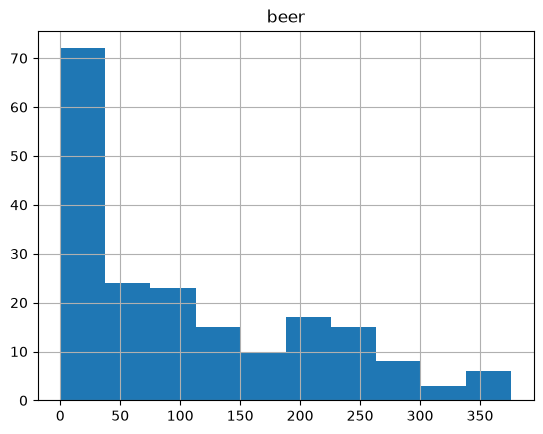

In [4]:
drinks.hist(column='beer',    # beer count 시각화)
            bins=10)          # 10개 구간

plt.savefig('image/1_1.png')  # 그래프 출력과 저장

In [5]:
# list available plot styles
plt.style.available

['Solarize_Light2',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'petroff6',
 'petroff8',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [6]:
plt.style.use('seaborn-v0_8-deep')        # 스타일 적용

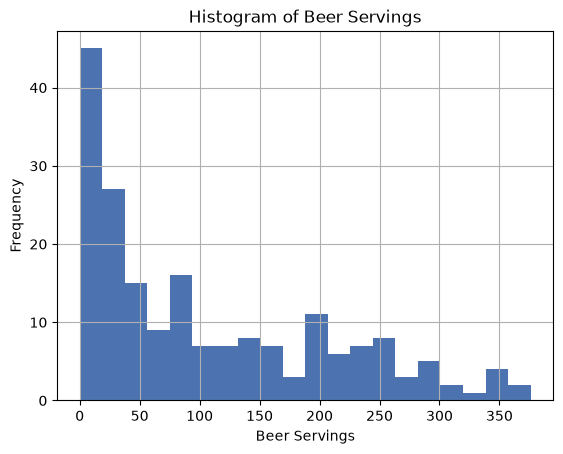

In [7]:
drinks.hist(column='beer',                # beer count 시각화)
            bins=20)                      # 20개 구간

plt.xlabel('Beer Servings')               # x축 레이블
plt.ylabel('Frequency')                   # y축 레이블
plt.title('Histogram of Beer Servings')   # 타이틀 추가

plt.savefig('image/1_2.png') 

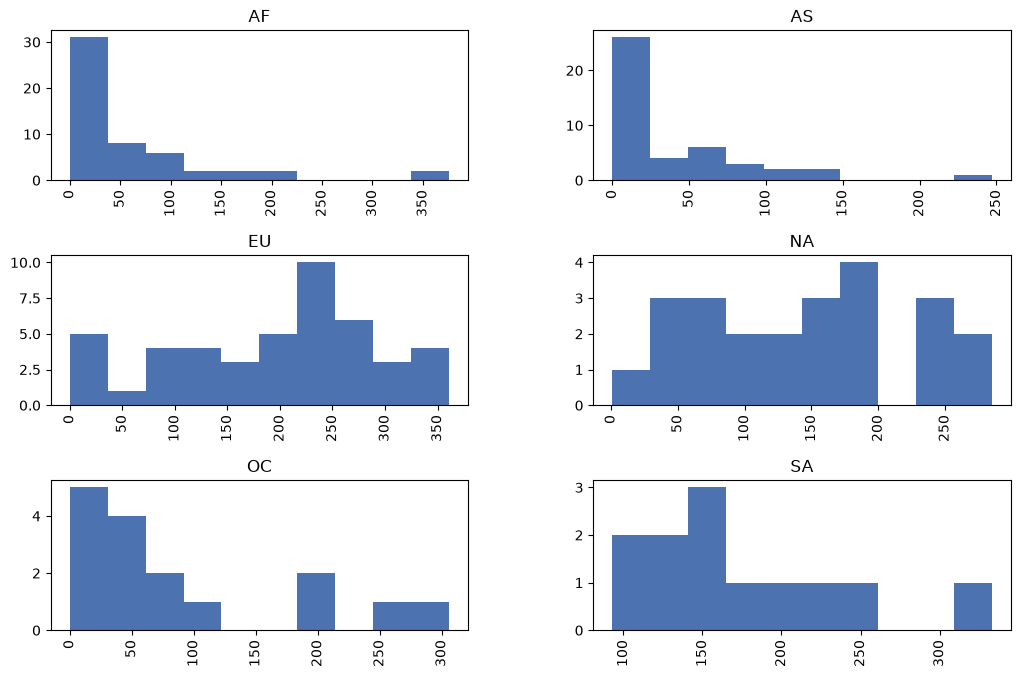

In [8]:
# AF, AS, EU, NA, OC, SA 대륙별 beer Histogram 6개 출력
# 기본 배치: 3행 × 2열
drinks.hist(column='beer', 
            by='continent',   # 대률별 출력
            figsize=(12, 8),   # 가로 12, 세로 8 인치
)



plt.savefig('image/1_3.png')

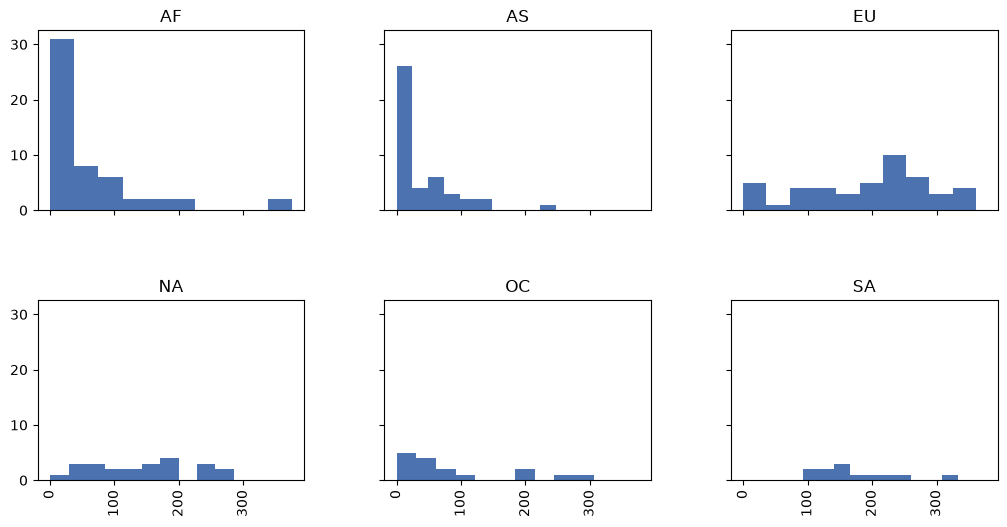

In [9]:
# x축과 y축 범위를 모두 동일하게 맞춤

drinks.hist(column='beer', 
            by='continent', 
            sharex=True,    # x 축 공유
            sharey=True,    # y 축 공유
            layout=(2, 3),   # 2 x 3으로 레이아웃 변경
            figsize=(12, 6)   # 가로 12, 세로 8 인치
            )

plt.savefig('image/1_4.png')

## 2. Scatter plot
Purpose: Showing the relationship between two numerical variables

**Marker**:
- http://matplotlib.org/1.5.1/examples/lines_bars_and_markers/marker_reference.html
- http://matplotlib.org/api/markers_api.html

**Line**:
- http://matplotlib.org/1.5.1/examples/lines_bars_and_markers/line_styles_reference.html
- http://matplotlib.org/api/lines_api.html

**Color**:
- http://matplotlib.org/examples/color/named_colors.html
- http://matplotlib.org/api/colors_api.html


In [10]:
# select the beer and wine columns and sort by beer
drinks[['beer', 'wine']].sort_values(by='beer')

,beer,wine
0,0,0
13,0,0
40,0,74
46,0,0
111,0,0
...,...,...
98,343,56
65,346,175
62,347,59
45,361,134


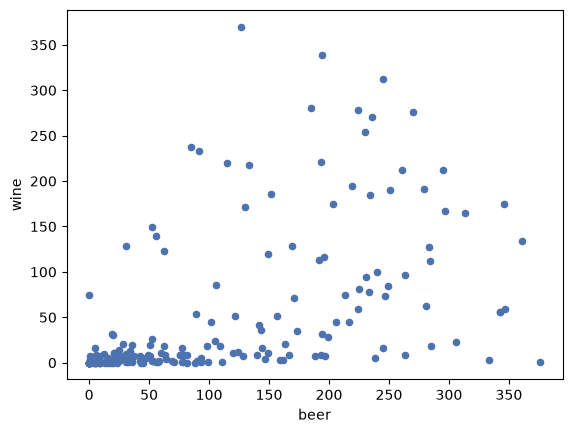

In [11]:
# compare with scatter plot
drinks.plot(kind='scatter', x='beer', y='wine')

plt.savefig('image/2_1.png')

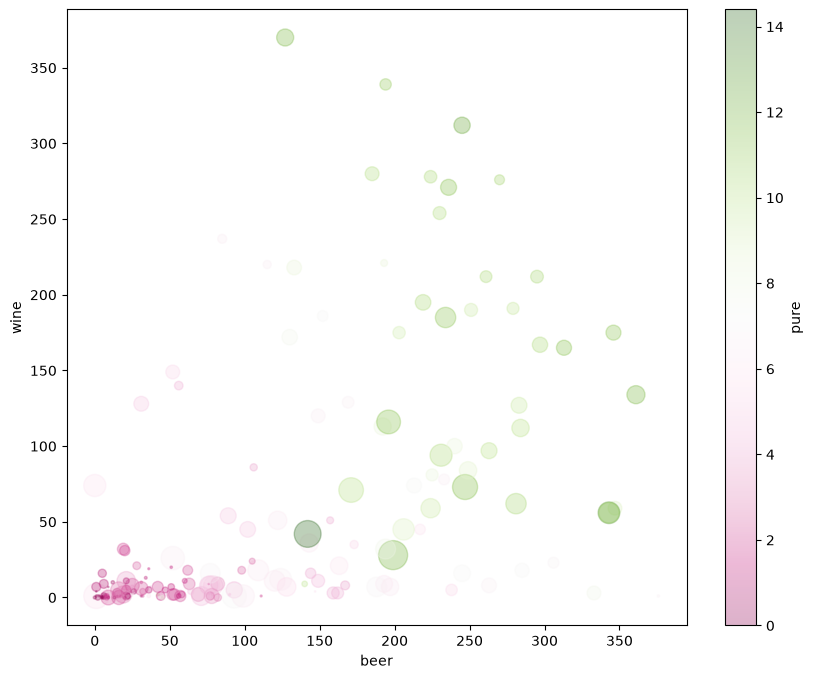

In [12]:
drinks.plot(kind='scatter', 
            x='beer', 
            y='wine', 
            s='spirit',         # 크기
            c='pure',           # 컬러
            colormap='PiYG',    # 컬러팔레트
            alpha=0.3,          # 투명도
            figsize=(10, 8),    # 이미지 크기
            )

plt.savefig('image/2_2.png')

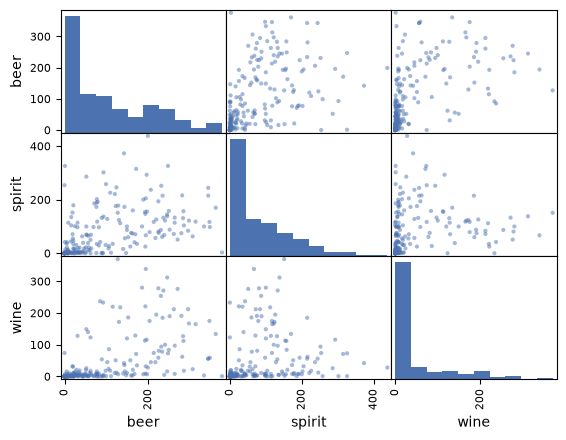

In [13]:
# scatter matrix of three numerical columns
pd.plotting.scatter_matrix(drinks[['beer', 'spirit', 'wine']])

plt.savefig('image/2_3.png')

## 3. Bar plot
Purpose: Showing a numerical comparison across different categories

In [14]:
# count the number of countries in each continent
drinks.continent.value_counts()

continent
AF    53
EU    45
AS    44
NA    23
OC    16
SA    12
Name: count, dtype: int64

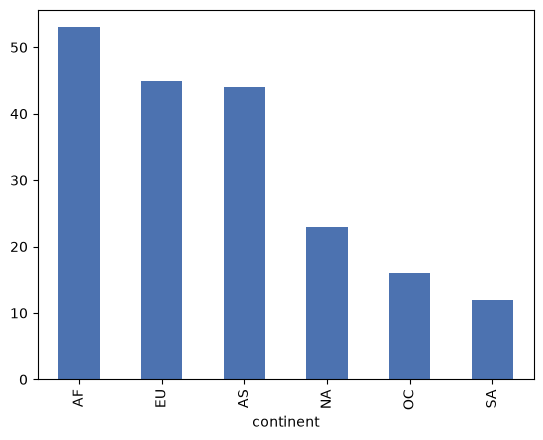

In [15]:
# AF, EU, AS, NA, OC, SA의 국가 수를 막대 높이로 비교하는 Bar plot 출력
drinks.continent.value_counts().plot(kind='bar')

plt.savefig('image/3_1.png')

In [16]:
# 대륙별 평균 소비량 계산
drink_continent=drinks.groupby(['continent'])[['beer',
                                               'spirit',
                                               'wine',
                                               'pure']].agg(['mean']).droplevel(axis=1,level=1).reset_index()
drink_continent

,continent,beer,spirit,wine,pure
0,AF,61.471698,16.339623,16.264151,3.007547
1,AS,37.045455,60.840909,9.068182,2.170455
2,EU,193.777778,132.555556,142.222222,8.617778
3,NA,145.434783,165.739130,24.521739,5.995652
4,OC,89.687500,58.437500,35.625000,3.381250
5,SA,175.083333,114.750000,62.416667,6.308333


In [17]:
drink_continent.dtypes

continent        str
beer         float64
spirit       float64
wine         float64
pure         float64
dtype: object

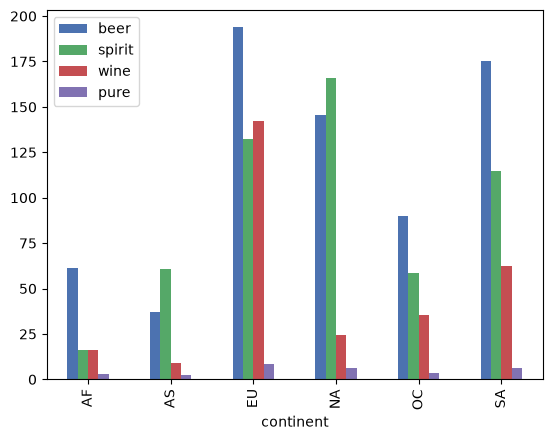

In [18]:
# side-by-side bar plots
drink_continent.plot(kind='bar', x='continent')

plt.savefig('image/3_2.png')

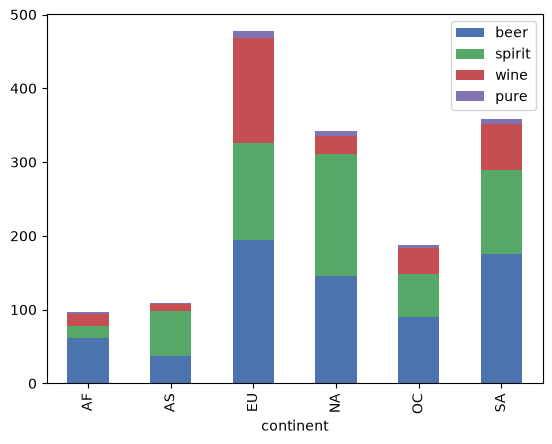

In [19]:
# stacked bar plots
drink_continent.plot(kind='bar', x='continent', stacked=True)

plt.savefig('image/3_3.png')

## 4. Box plot
Purpose: Showing quartiles and outliers for one or more numerical variables

**Five-number summary:**

- min = minimum value
- 25% = first quartile (Q1) = median of the lower half of the data
- 50% = second quartile (Q2) = median of the data
- 75% = third quartile (Q3) = median of the upper half of the data
- max = maximum value

(More useful than mean and standard deviation for describing skewed distributions)

**Interquartile Range (IQR)** = Q3 - Q1

**Outliers:**

- below Q1 - 1.5 * IQR
- above Q3 + 1.5 * IQR

In [20]:
# sort the spirit column
drinks.spirit.sort_values(ascending=True)

0        0
2        0
13       0
19       0
27       0
      ... 
144    315
141    326
73     326
15     373
68     438
Name: spirit, Length: 193, dtype: int64

In [21]:
# show "five-number summary" for spirit
drinks.spirit.describe()

count    193.000000
mean      80.994819
std       88.284312
min        0.000000
25%        4.000000
50%       56.000000
75%      128.000000
max      438.000000
Name: spirit, dtype: float64

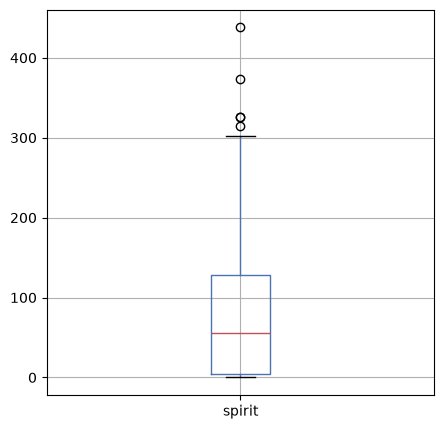

In [22]:
# compare with box plot
drinks.boxplot(column='spirit', figsize=(5, 5))

plt.savefig('image/4_1.png')

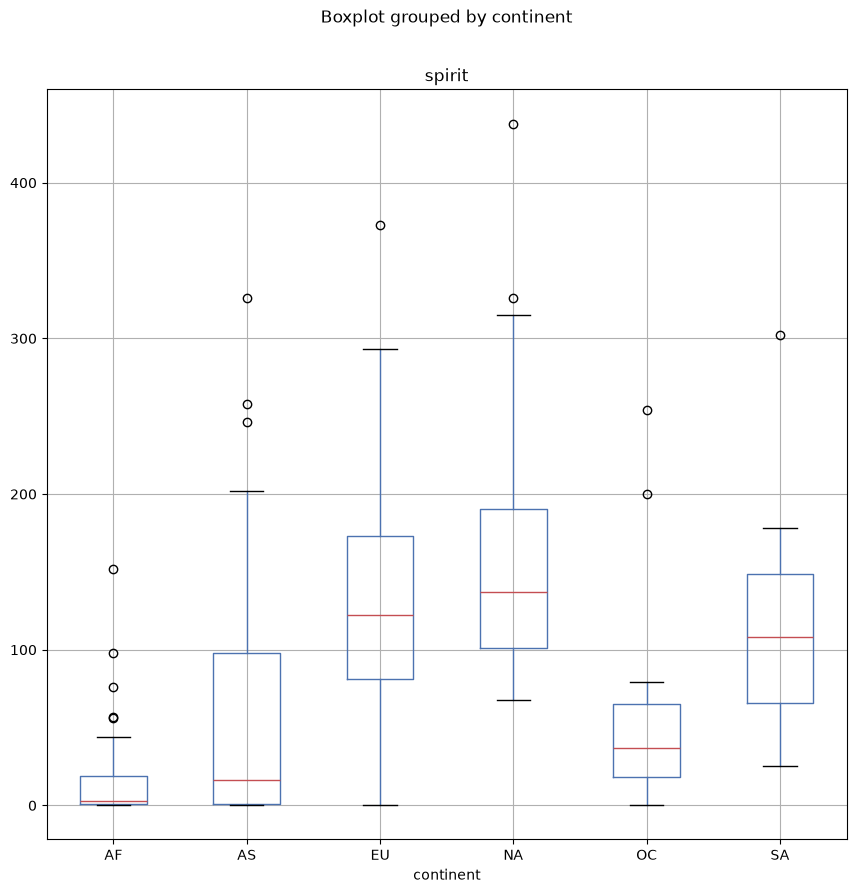

In [23]:
# box plot of beer servings grouped by continent
drinks.boxplot(column='spirit', by='continent', figsize=(10, 10))

plt.savefig('image/4_2.png')

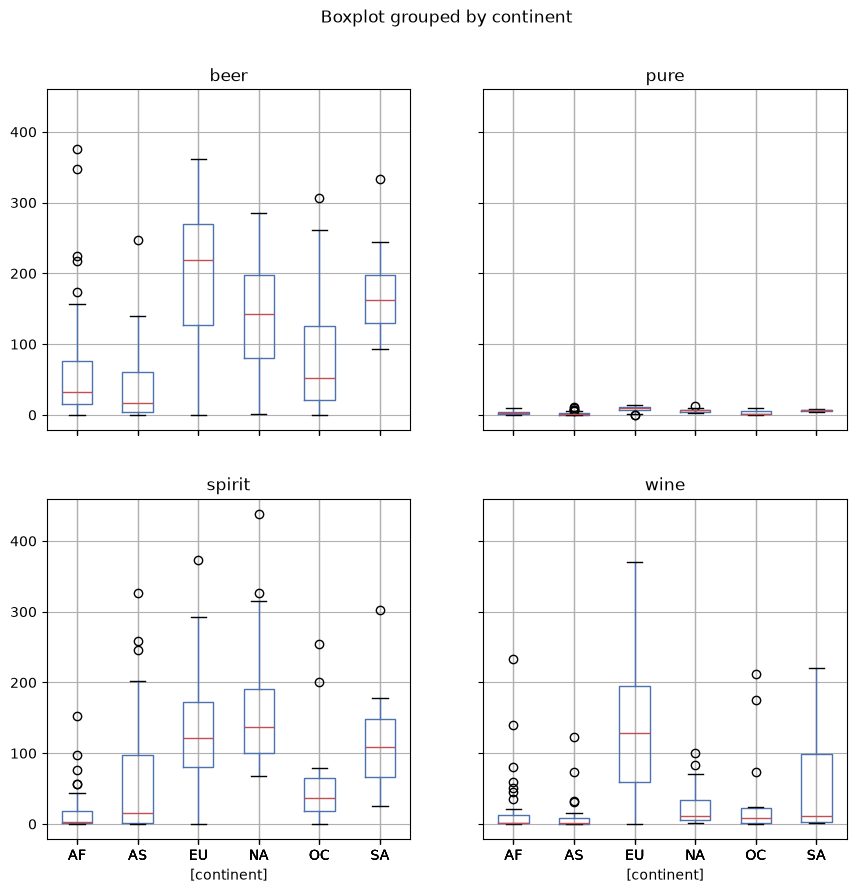

In [24]:
# box plot of all numeric columns grouped by continent
drinks.boxplot(by='continent', figsize=(10, 10))

plt.savefig('image/4_3.png')

## 5. Line plot
Purpose: Showing the trend of a numerical variable over time

In [25]:
# read in the ufo data
url = 'https://raw.githubusercontent.com/justmarkham/DAT8/master/data/ufo.csv'
ufo = pd.read_csv(url)
ufo['Time'] = pd.to_datetime(ufo.Time)
ufo['YearMonth'] = ufo.Time.dt.to_period('M')
ufo

,City,Colors Reported,Shape Reported,State,Time,YearMonth
0,Ithaca,NaN,TRIANGLE,NY,1930-06-01 22:00:00,1930-06
1,Willingboro,NaN,OTHER,NJ,1930-06-30 20:00:00,1930-06
2,Holyoke,NaN,OVAL,CO,1931-02-15 14:00:00,1931-02
3,Abilene,NaN,DISK,KS,1931-06-01 13:00:00,1931-06
4,New York Worlds Fair,NaN,LIGHT,NY,1933-04-18 19:00:00,1933-04
...,...,...,...,...,...,...
80538,Neligh,NaN,CIRCLE,NE,2014-09-04 23:20:00,2014-09
80539,Uhrichsville,NaN,LIGHT,OH,2014-09-05 01:14:00,2014-09
80540,Tucson,RED BLUE,NaN,AZ,2014-09-05 02:40:00,2014-09
80541,Orland park,RED,LIGHT,IL,2014-09-05 03:43:00,2014-09


In [26]:
ufo.dtypes

City                          str
Colors Reported               str
Shape Reported                str
State                         str
Time               datetime64[us]
YearMonth               period[M]
dtype: object

In [27]:
# 월별 UFO 목격 횟수 
ufo_count = ufo.YearMonth.value_counts().sort_index()

# 1970년 1월 이후만 추출
ufo_count_after_1970 = ufo_count[
    ufo_count.index >= pd.Period('1970-01', freq='M')
]

ufo_count_after_1970

YearMonth
1970-01       8
1970-02       6
1970-03       5
1970-04       3
1970-05      10
           ... 
2014-05     593
2014-06     710
2014-07    1006
2014-08     779
2014-09      97
Freq: M, Name: count, Length: 536, dtype: int64

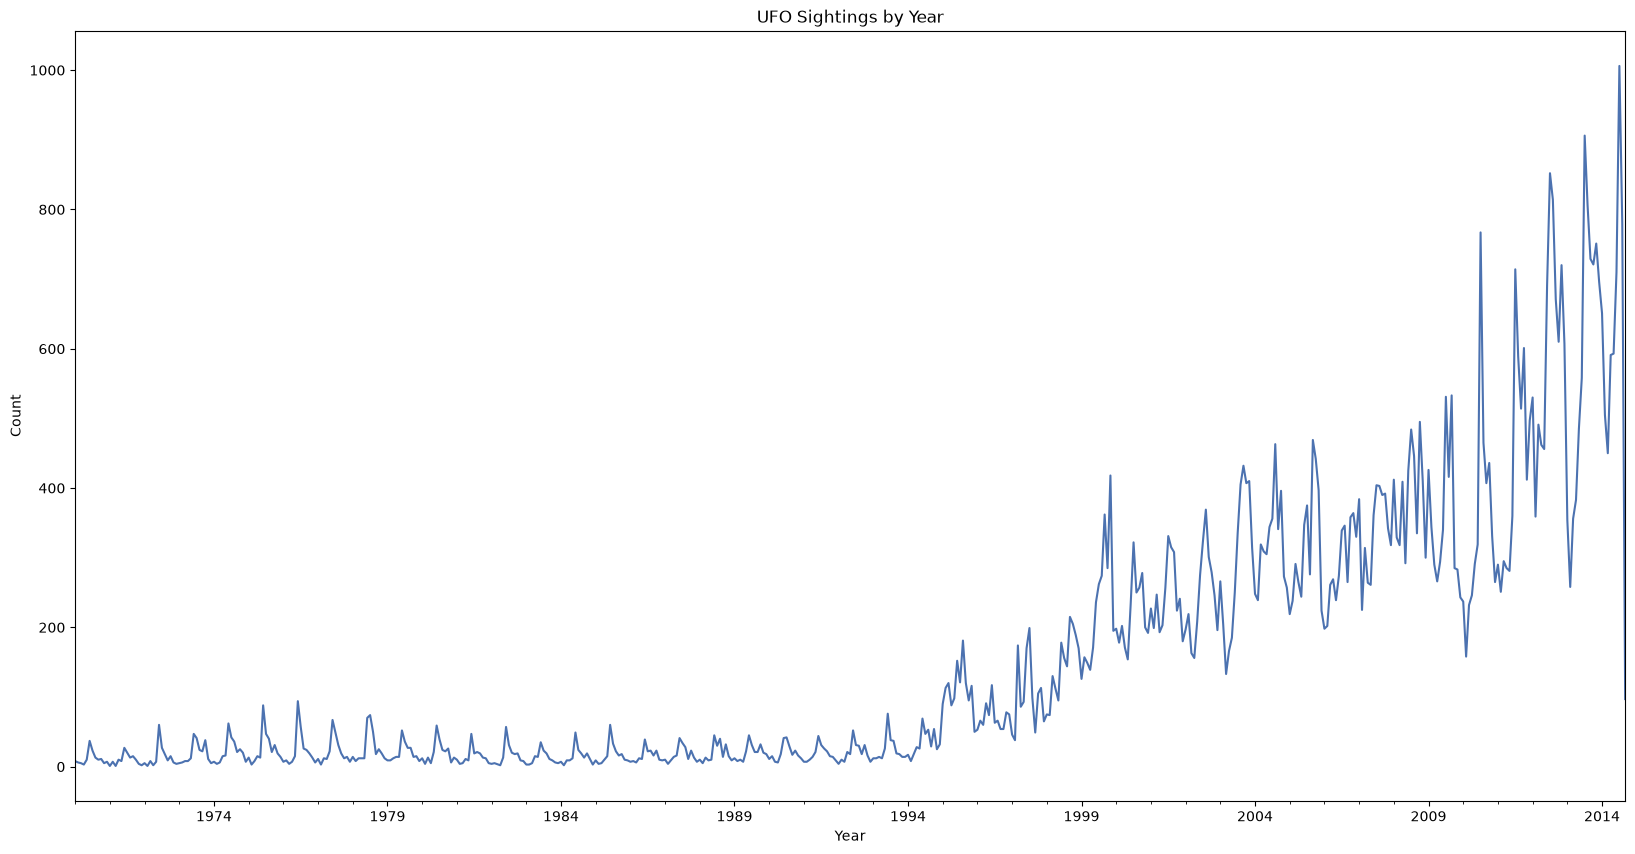

In [28]:
# 선그래프로 시각화
ufo_count_after_1970.plot.line(
    xlabel='Year',
    ylabel='Count',
    title='UFO Sightings by Year',
    figsize=(20, 10)
)

plt.savefig('image/5_1.png')